In [9]:
import sys

sys.path.append("..")

from utils.orientation_map import *
from utils.generation import *
from utils.filters import *
from utils.density_map import *

import torch
import cv2

In [10]:
def select_and_merge_density_maps(width, height):
    freq1 = load_random_density_map()
    freq2 = load_random_density_map()

    # Possibly load a third map
    flag_3 = rand() > 0.5
    freq3 = load_random_density_map() if flag_3 else None

    # Merge maps
    if flag_3:
        freq = (freq1 + freq2 + freq3) / 3 / 255.0
    else:
        freq = (freq1 + freq2) / 2 / 255.0

    # Resize to target dimensions, normalize to [0, 1]
    f_den = cv2.resize(freq, (width, height), interpolation=cv2.INTER_LINEAR)
    f_den = (f_den - np.min(f_den)) / (np.max(f_den) - np.min(f_den))

    return f_den

In [11]:
width = 256
height = 256



def get_spiral_phase(psi, points, polarities):
    H, W = psi.shape
    Y, X = np.mgrid[:H, :W]
    zero = np.zeros_like(psi)
    for (yy, xx), p in zip(points, polarities):
        zero += p * np.arctan2(Y - yy, X - xx)

    return zero

def generate_heatmap(minutiae, h, w, sigma=3):
    """
    Converts list of (x, y) points into a Gaussian heatmap.
    """
    heatmap = torch.zeros((h, w))

    # Create a coordinate grid
    y_grid, x_grid = torch.meshgrid(torch.arange(h), torch.arange(w), indexing="ij")

    for x, y, _ in minutiae:
        # Simple Gaussian stamp
        # Check bounds
        if 0 <= x < w and 0 <= y < h:
            dist_sq = (x_grid - x) ** 2 + (y_grid - y) ** 2
            heatmap += torch.exp(-dist_sq / (2 * sigma**2))

    # Normalize heatmap to [0, 1] for stability
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    return heatmap.unsqueeze(0)  # Add channel dim -> (1, H, W)

In [12]:
from model import FingerprintUNet

model = FingerprintUNet(in_channels=3, out_channels=2)
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint = torch.load('../checkpoints/ckpt_parallel_1e-3.pth', map_location=torch.device(device))

model.load_state_dict(checkpoint["model"])
model.to(device)
model.eval()



FingerprintUNet(
  (encoder1): Sequential(
    (enc1conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu1): ReLU(inplace=True)
    (enc1conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc1norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc1relu2): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (encoder2): Sequential(
    (enc2conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (enc2relu1): ReLU(inplace=True)
    (enc2conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (enc2norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

In [15]:
singularity_type = 1


core_positions, delta_positions, arch_fact1, arch_fact2, k_arch = init_para_canonical(
    H=height, W=width, singularity_type=singularity_type
)
g_cap = set_param_canonical(singularity_type)

o_map = OrientationMap(
    width,
    height,
    singularity_type,
    delta_positions,
    core_positions,
    g_cap,
    arch_fact1,
    arch_fact2,
    k_arch,
)

orientation_map = o_map.getOrientationMap()

minutiae = []
for _ in range(40):
    y = random.randint(12, 230)
    x = random.randint(12, 230)
    minutiae.append((x, y, random.choice([-1, 1])))

cos_2_theta = torch.from_numpy(np.cos(2 * orientation_map)).float()
sin_2_theta = torch.from_numpy(np.sin(2 * orientation_map)).float()
# minutiae_heatmap = generate_heatmap(minutiae, height, width, sigma=3)


freq_map = select_and_merge_density_maps(width, height)
freq_map_jitter = (
    (freq_map - np.min(freq_map)) / (np.max(freq_map) - np.min(freq_map)) * 0.05
)
base_freq = np.random.uniform(0.057, 0.153)
freq_map = base_freq + freq_map_jitter

inputs = torch.cat(
    [sin_2_theta.unsqueeze(0), cos_2_theta.unsqueeze(0), torch.from_numpy(freq_map).float().unsqueeze(0)], dim=0
)

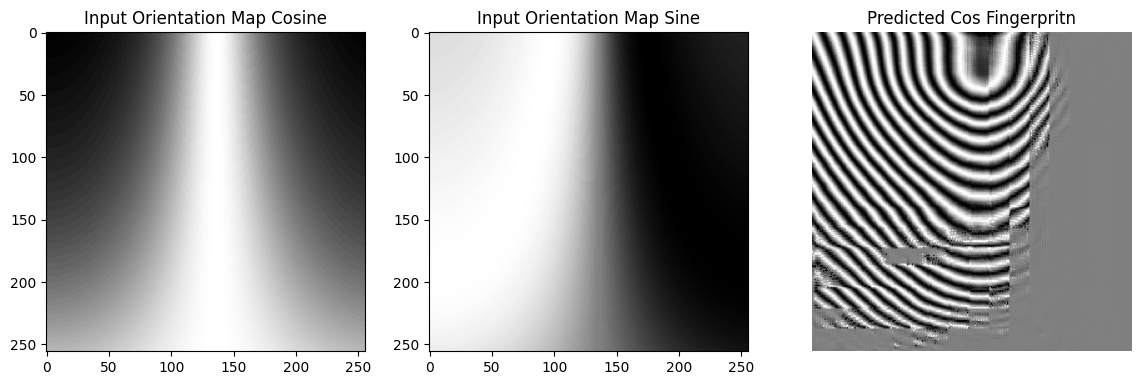

In [16]:
sp = get_spiral_phase(
    orientation_map, [(y, x) for x, y, _ in minutiae], [p for _, _, p in minutiae]
)

with torch.no_grad():
    input_tensor = inputs.unsqueeze(0).to(device)  # Add batch dim
    output = model(input_tensor)
    pred_sin = output[:, 0:1, :, :].squeeze().cpu().numpy()
    pred_cos = output[:, 1:2, :, :].squeeze().cpu().numpy()

plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
plt.imshow(cos_2_theta.numpy(), cmap="gray")
plt.title("Input Orientation Map Cosine")

plt.subplot(1, 3, 2)
plt.imshow(sin_2_theta.numpy(), cmap="gray")
plt.title("Input Orientation Map Sine")

plt.subplot(1, 3, 3)
plt.imshow(pred_cos, cmap="gray")
plt.title("Predicted Cos Fingerpritn")
plt.axis("off")
plt.show()